In [89]:
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import pykitti

from pathlib import Path

In [90]:
base = Path.home() / "SensorTrust" / "datasets" / "kitti"

data = pykitti.raw(
    base_path=str(base),
    date="2011_09_26",
    drive="0009"
)

print(f"LiDAR frames: {len(data.velo_files)}")
print(f"Camera frames: {len(data.cam2_files)}")

LiDAR frames: 443
Camera frames: 447


In [91]:
frame_id = 100   # try 0, 50, 100, 200 etc.

scan = data.get_velo(frame_id)

print("Scan shape:", scan.shape)

Scan shape: (115964, 4)


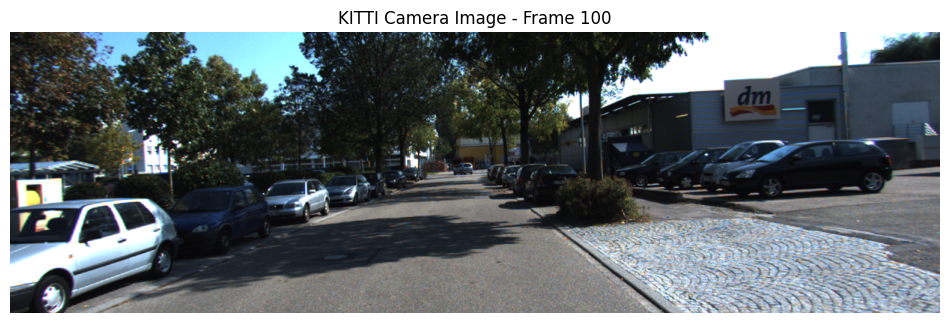

In [92]:
import matplotlib.pyplot as plt
import numpy as np

frame_id = 100   # use the same frame as your LiDAR

img = np.array(data.get_cam2(frame_id))

plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.title(f"KITTI Camera Image - Frame {frame_id}")
plt.axis("off")
plt.show()

In [93]:
xyz = scan[:, :3]

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz)

pcd

PointCloud with 115964 points.

In [94]:
'''point cloud visualization'''
o3d.visualization.draw_geometries(
    [pcd],
    window_name=f"KITTI Frame {frame_id}"
)

In [95]:
pcd = pcd.voxel_down_sample(voxel_size=0.15)

print("Downsampled points:", len(pcd.points))

Downsampled points: 39092


In [96]:
plane_model, inliers = pcd.segment_plane(
    distance_threshold=0.2,
    ransac_n=3,
    num_iterations=1000
)

objects = pcd.select_by_index(
    inliers,
    invert=True
)

print("Object points:", len(objects.points))

Object points: 22746


In [97]:

o3d.visualization.draw_geometries(
    [objects],
    window_name="Ground Removed"
)

In [98]:
labels = np.array(
    objects.cluster_dbscan(
        eps=0.8,
        min_points=20,
        print_progress=True
    )
)

print("Clusters found:", labels.max() + 1)

Clusters found: 96


In [99]:
'''dbscan clustering algo demo'''

max_label = labels.max()

colors = plt.get_cmap("tab20")(
    labels / (max_label if max_label > 0 else 1)
)

colors[labels < 0] = [0, 0, 0, 1]

objects.colors = o3d.utility.Vector3dVector(
    colors[:, :3]
)

o3d.visualization.draw_geometries(
    [objects],
    window_name="Clustered Objects"
)

In [100]:
'''creating oriental bounding boxes'''

geometries = [objects]

for cluster_id in range(max_label + 1):

    indices = np.where(labels == cluster_id)[0]

    if len(indices) < 30:
        continue

    cluster = objects.select_by_index(indices)

    bbox = cluster.get_axis_aligned_bounding_box()
    bbox.color = (1, 0, 0)

    geometries.append(bbox)

o3d.visualization.draw_geometries(
    geometries,
    window_name="Object Detection"
)